<a href="https://colab.research.google.com/github/trupthinazre/AI-Resume-Screening-System/blob/main/SNA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Social Network Analysis and Centrality Mapping of Zachary’s Karate Club**


## **Setup and Data Loading**

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Load Zachary's Karate Club dataset built into NetworkX
G = nx.karate_club_graph()

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 34
Edges: 78


# **Calculate Centralities**

In [3]:
# Compute centrality scores
deg_cent = nx.degree_centrality(G)
close_cent = nx.closeness_centrality(G)
between_cent = nx.betweenness_centrality(G)

# Create summary table
df = pd.DataFrame({
    'Node': list(G.nodes()),
    'Club Faction': [G.nodes[n]['club'] for n in G.nodes()],
    'Degree Centrality': [round(deg_cent[n], 4) for n in G.nodes()],
    'Closeness Centrality': [round(close_cent[n], 4) for n in G.nodes()],
    'Betweenness Centrality': [round(between_cent[n], 4) for n in G.nodes()]
})

# Display top 5 most central nodes by betweenness
display(df.sort_values(by='Betweenness Centrality', ascending=False).head(5))

,Node,Club Faction,Degree Centrality,Closeness Centrality,Betweenness Centrality
0,0,Mr. Hi,0.4848,0.5690,0.4376
33,33,Officer,0.5152,0.5500,0.3041
32,32,Officer,0.3636,0.5156,0.1452
2,2,Mr. Hi,0.3030,0.5593,0.1437
31,31,Officer,0.1818,0.5410,0.1383


# **Structural Metrics (Transitivity, Reciprocity & Assortativity)**

In [4]:
transitivity = nx.transitivity(G)
reciprocity = nx.overall_reciprocity(G) if G.is_directed() else 1.0
assortativity = nx.degree_assortativity_coefficient(G)

print(f"Global Transitivity (Clustering): {transitivity:.4f}")
print(f"Reciprocity: {reciprocity:.4f}")
print(f"Degree Assortativity: {assortativity:.4f}")

Global Transitivity (Clustering): 0.2557
Reciprocity: 1.0000
Degree Assortativity: -0.4756


# **Visualization Plot**

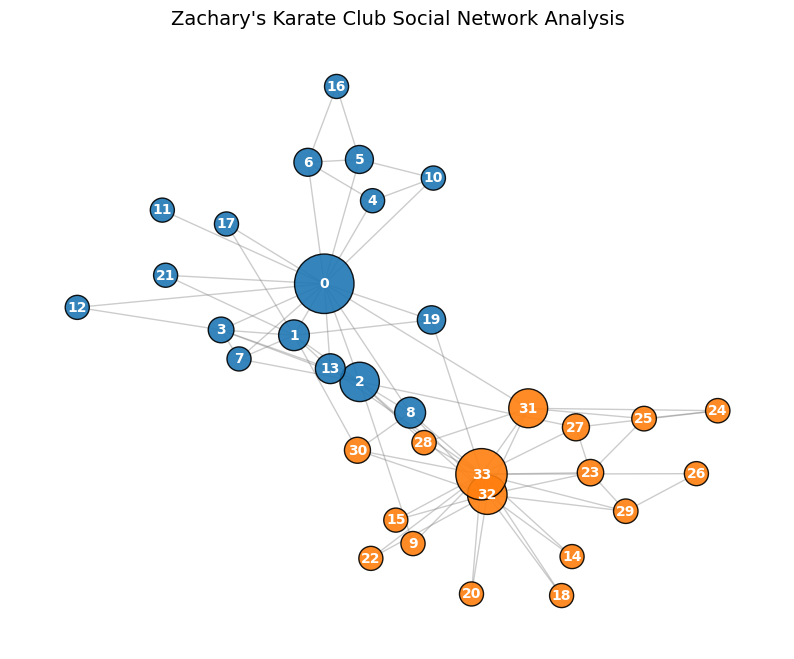

In [5]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

# Color nodes by faction ('Mr. Hi' vs 'Officer')
colors = ['#1f77b4' if G.nodes[n]['club'] == 'Mr. Hi' else '#ff7f0e' for n in G.nodes()]

# Node size relative to betweenness centrality
node_sizes = [between_cent[n] * 3500 + 300 for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=colors, alpha=0.9, edgecolors='black')
nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='white')

plt.title("Zachary's Karate Club Social Network Analysis", fontsize=14)
plt.axis('off')
plt.show()